In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine import nested_cv
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics

N_STORES = 3
DAYS     = 500
FORECAST_HORIZON = 15

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

def make_synthetic_sales_data():
    dates    = pd.date_range("2013-01-01", periods=DAYS, freq="D")
    rows = []
    rng  = np.random.default_rng(C.SEED)
    for store_id in range(1, N_STORES + 1):
        base = 300 + store_id * 150          # stores differ in overall level
        for date in dates:
            dow      = date.dayofweek + 1    # 1=Mon … 7=Sun
            is_sun   = dow == 7
            seasonal = base + 20 * np.sin(2 * np.pi * (dow - 1) / 6)   # peak Wed
            trend    = 0.2 * (date - dates[0]).days
            promo    = int(rng.random() < 0.25)
            sales    = max(0.0, seasonal + trend + promo * 100) if not is_sun else 0.0
            rows.append({
                "Date":          date,
                "Store":         store_id,
                "DayOfWeek":     dow,
                "Open":          0 if is_sun else 1,
                "Promo":         promo,
                "StateHoliday":  "0",
                "SchoolHoliday": 0,
                "Sales":         sales,
            })

    train = pd.DataFrame(rows)

    return train

def make_synthetic_store_data():

    stores = pd.DataFrame({
        "Store":               list(range(1, N_STORES + 1)),
        "StoreType":           ["a", "b", "c"],
        "Assortment":          ["a", "a", "b"],
        "CompetitionDistance": [500.0, 1200.0, 800.0],
        "CompetitionSinceDate": pd.to_datetime(["2012-03-01", "2011-06-01", "2013-01-01"]),
        "Promo2SinceDate":     pd.to_datetime(["2012-06-01", pd.NaT,       "2013-03-01"]),
        "PromoInterval":       ["Jan,Apr,Jul,Oct", None,                   "Mar,Jun,Sep,Dec"],
    })

    return stores


c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 467.520508         a          a                500.0           2012-03-01      2012-06-01       1
         4     1      0            0              0 450.400000         a          a                500.0           2012-03-01      2012-06-01       1
         5     1      0            0              0 433.279492         a          a                500.0           2012-03-01      2012-06-01       1
         6     1      1            0              0 533.479492         a          a                500.0           2012-03-01      2012-06-01       1


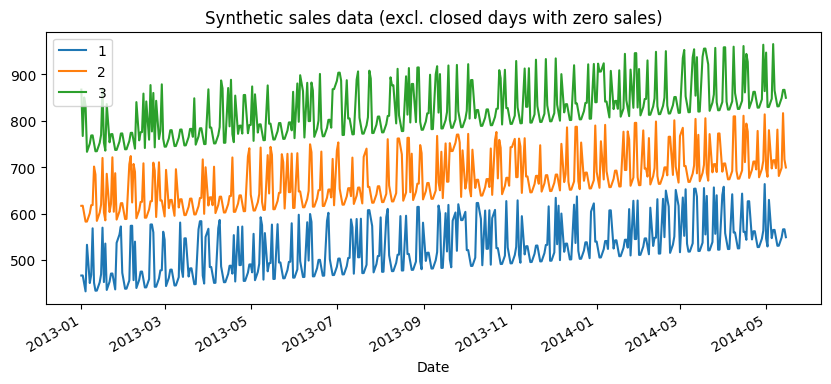

In [2]:
stores = make_synthetic_store_data()
train = make_synthetic_sales_data()
df  = attach_store_data(train, stores).set_index(["Date", "Store"])

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "outer_train_size": 150, #C.OUTER_TRAIN_SIZE,
    "inner_train_size": 80, #C.INNER_TRAIN_SIZE,
}

study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [ ]:
from typing import Any
from sklearn.model_selection import BaseCrossValidator
from optuna.trial import Trial, TrialState
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from optuna_integration.xgboost import XGBoostPruningCallback
from src.engine.hypertuning import _objective
from src.engine import utils

from typing import Literal

def overwrite_closed_sales(
        sales: pd.Series,
        mode: Literal['interpolate', 'zero'],
        index_name: str = "Date"
        ) -> pd.Series:
    """ 
    Re-interpolate sales for days when the store was closed (Sundays) with non-zero sales on adjacent days.

    Args
        sales: Series indexed by ['Date', 'Store'].
        mode: Method to handle closed days. 'interpolate' fills closed days with interpolated values based on adjacent days' sales, while 'zero' fills closed days with zeros.
        index_name: Name of the index level representing the date.
    
    Returns
        Series with same structure as input, but with 'Sales' re-interpolated for closed days.
    """
    is_closed = sales.index.get_level_values(index_name).day_name() == 'Sunday'
    sales.loc[is_closed] = np.nan

    if mode == 'interpolate':
        sales = (sales
                 .unstack('Store')
                 .interpolate(method='time')
                 .stack('Store'))

    elif mode == 'zero':
        sales.loc[is_closed] = 0

    return sales


def wide_to_long_predictions(s: pd.DataFrame) -> pd.Series:
    """ Convert wide-format predictions with MultiIndex (Date, Store) and columns for each day ahead
        to long-format predictions with MultiIndex (Date, Store, Forecast Date) and a single value column.

        Args:
            s: DataFrame with MultiIndex (Date, Store) and columns for each day ahead

        Returns:
            Series with MultiIndex (Date, Store, Forecast Date) and values containing the predictions.
    """

    # Transform preds from wide format to long format
    # Current format: MultiIndex (Date, Store), columns are days ahead (1, 2, 3, ...)
    # Target format: MultiIndex (Date, Store, Forecast Date), single value column

    # Reset index to make Date and Store regular columns
    s_long = s.reset_index()

    # Melt from wide to long format
    s_long = s_long.melt(id_vars=["Date", "Store"],
                         var_name="lead_column",
                         value_name="value")

    # Extract days ahead from column name (e.g., "lead_1_days" -> 1)
    s_long['days_ahead'] = (s_long['lead_column'].astype(int) + 1)

    # Calculate forecast date by adding days to the base Date
    s_long['Forecast Date'] = s_long['Date'] + pd.to_timedelta(s_long['days_ahead'], unit='D')

    # Create the final long-format dataframe with MultiIndex (Date, Store, Forecast Date)
    s_long = (s_long
              .set_index(['Date', 'Store', 'Forecast Date'])
              .drop(['lead_column', 'days_ahead'], axis=1)
              ['value']  # Implicitly convert to Series
              .sort_index())

    return s_long


def predict(booster: xgb.Booster, X_test: pd.DataFrame) -> pd.Series:
    """ 
    Generate predictions for the given test data using the provided XGBoost booster.

    Args:
        booster: Trained XGBoost booster.
        X_test: Test features.

    Returns:
        Series with predictions.
    """
    test_dmatrix  = xgb.DMatrix(X_test, enable_categorical=True)
    log_preds_raw = booster.predict(test_dmatrix)
    log_preds = pd.DataFrame(data=log_preds_raw, index=X_test.index)
    preds_long = wide_to_long_predictions(log_preds)
    preds = overwrite_closed_sales(preds_long, mode='zero', index_name="Forecast Date")
    preds = preds.apply(np.expm1)

    return preds

def refit(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    best_trial: optuna.trial.FrozenTrial,
    model_config: dict[str, Any],
    seed: int
) -> xgb.Booster:
    """ 
    Refit XGBoost model on the entire outer fold training set using the best hyperparameters found in the inner loop.

    Args:
        X_train: Training features for the outer fold.
        y_train: Training targets for the outer fold.
        best_trial: Optuna trial object containing the best hyperparameters from the inner loop.
        model_config: Dictionary containing any constant hyperparameters for the XGBoost model.
        seed: Random seed for reproducibility.

    Returns:
        Trained XGBoost booster fitted on the entire outer fold training set with the best hyperparameters.
    """
    params = {**model_config, **best_trial.params}
    num_boost_round = best_trial.user_attrs["best_n_rounds"]
    train_dmatrix = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    booster = xgb.train(params=params,
                        num_boost_round=num_boost_round,
                        dtrain=train_dmatrix)

    return booster


def optimize(study_name: str, X_train: pd.DataFrame, y_train: pd.Series, config: dict) -> None:
    """ 
    Optimize hyperparameters using Optuna with nested cross-validation.

    Args:
        study_name (str): Name of the Optuna study.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training targets.
        config (dict): Configuration dictionary for the study.

    Returns:
        None
    """

    inner_cv = TimeSeriesCV(n_splits=config["n_inner_splits"],
                            horizon=config["forecast_horizon"],
                            train_size=config["inner_train_size"])
    
    pruner = MedianPruner(n_startup_trials=config["n_startup_trials"])

    sampler = TPESampler(seed=config["seed"])

    obj_fcn = lambda trial: _objective(trial, X_train, y_train, inner_cv,
                                       study_name=study_name,
                                       study_config=config)

    study = optuna.create_study(study_name=study_name,
                                storage=config["storage_url"],
                                load_if_exists=True,
                                direction="minimize",
                                pruner=pruner,
                                sampler=sampler)

    finished_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED, TrialState.COMPLETE])
    remaining_trials = config["n_trials"] - len(finished_trials)

    study.optimize(obj_fcn, n_trials=remaining_trials, n_jobs=config["n_jobs"])
    utils.log_study(study)

    return

In [ ]:

# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. Log-transform the target
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)
df['Sales'] = overwrite_closed_sales(df['Sales'], mode='interpolate').apply(np.log1p)
X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y = make_targets(df['Sales'], C.FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                    horizon=cv_config["forecast_horizon"],
                    train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = refit(X_train, y_train, study.best_trial, study_config, seed=C.SEED)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = predict(booster, X_test)
    
    # Log metrics
    actuals_index = preds.index.droplevel("Date").swaplevel("Store")  # Align with original df index to get actual sales
    actuals = df.loc[actuals_index, 'Sales'].apply(np.expm1)
    metrics = compute_metrics(actuals.values, preds.values)
    metrics = {metric: round(value, 3) for metric, value in metrics.items()}
    logger.info(f"Test set metrics for fold {fold}: {metrics}")

    break


In [ ]:
y_log = y.apply(np.log1p)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                    horizon=cv_config["forecast_horizon"],
                    train_size=cv_config["outer_train_size"])

for fold, (outer_train_idx, outer_test_idx) in enumerate(cv.split(X), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    # Make fold-specific artifact paths for boosters and metrics
    logger.info(f"Setting up artifact paths for fold {fold}...")
    study_name = f"study_fold_{fold}"
    artifact_dir = os.path.join(study_config["log_dir"], study_name)
    booster_filename = os.path.join(artifact_dir, f"booster_fold_{fold}.model")
    metrics_filename = os.path.join(artifact_dir, f"test_set_metrics_fold_{fold}.csv")
    predictions_filename = os.path.join(artifact_dir, f"predicted_sales_fold_{fold}.csv")
    actual_filename = os.path.join(artifact_dir, f"actual_sales_fold_{fold}.csv")
    os.makedirs(artifact_dir, exist_ok=True)

    # Evaluate final model on the outer fold test set and log metrics
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = booster.predict(test_dm)
    is_closed = Xv['Open'] == 0
    preds = set_zero_sales_on_closed(preds, is_closed)
    preds = pd.DataFrame(data=np.expm1(preds),  # Invert log1p transformation
                            index=Xv.index,
                            columns=yv.columns)
    yv = ylog_v.apply(np.expm1)  # Invert log1p transformation for actuals

    metrics = compute_metrics(yv, preds)
    metrics.to_csv(metrics_filename)
    booster.save_model(booster_filename)
    preds.to_csv(predictions_filename)
    yv.to_csv(actual_filename)
    utils.plot_results(yv, preds)
    plt.savefig(os.path.join(artifact_dir, "predictions.png"))

logger.info("Nested cross-validation complete. All results logged.")

return 

In [ ]:
print("Building features …")
df  = attach_store_data(train.copy(), stores.copy())
df['Sales'] = df['Sales'].apply(np.log1p)

X  = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y   = make_targets(df[["Date", "Store", "Sales"]], horizon=FORECAST_HORIZON)
X, y = drop_closed(X, y)
X, y = drop_null_targets(X, y)

print(f"X: {X.shape}   y: {y.shape}")
print(f"Unique dates: {X.index.get_level_values('Date').nunique()}   "
      f"Stores: {sorted(X.index.get_level_values('Store').unique().tolist())}")

# Run nested CV
print("\nRunning nested CV …")
nested_cv(X, y, cv_config, study_config)

# TODO: Cleanup nested_cv, return all predictions in the same format as the actuals.

Building features …
X: (1248, 78)   y: (1248, 15)
Unique dates: 416   Stores: [1, 2, 3]

Running nested CV …
[0]	train-rmse:0.70767+0.00082	test-rmse:0.70891+0.00451
[0]	train-rmse:0.70052+0.00041	test-rmse:0.70732+0.00376
[0]	train-rmse:0.66897+0.00043	test-rmse:0.68943+0.01111
[0]	train-rmse:0.70685+0.00083	test-rmse:0.70935+0.00420
[14]	train-rmse:0.27672+0.02254	test-rmse:0.71140+0.01177
[0]	train-rmse:0.69382+0.00125	test-rmse:0.70260+0.00497
[28]	train-rmse:0.51518+0.00233	test-rmse:0.67316+0.00125
[0]	train-rmse:0.65145+0.00708	test-rmse:0.69927+0.00078
[11]	train-rmse:0.25411+0.01586	test-rmse:0.74708+0.01086
[0]	train-rmse:0.68805+0.00026	test-rmse:0.69954+0.00302
[28]	train-rmse:0.39605+0.00487	test-rmse:0.67368+0.00534
[0]	train-rmse:0.70016+0.00080	test-rmse:0.70883+0.00394
[32]	train-rmse:0.30179+0.01118	test-rmse:0.66809+0.01508
[0]	train-rmse:0.70667+0.00045	test-rmse:0.70880+0.00411
[0]	train-rmse:0.68480+0.00080	test-rmse:0.70786+0.00319
[0]	train-rmse:0.50397+0.00060	

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:

nested_cv(X, y, cv_config, study_config)

# 6. Print test-set metrics
print("Test set metrics per outer fold")
for fold_no in range(cv_config["n_outer_splits"]):
    metrics_path = os.path.join(C.LOG_DIR,
                                f"study_fold_{fold_no+1}", 
                                f"test_set_metrics_fold_{fold_no+1}.csv")
    metrics_df = pd.read_csv(metrics_path)
    print(f"\nFold {fold_no}:")
    print(metrics_df.to_string(index=False))

In [ ]:
# Extract last fold's train and test sets
outer_cv = TimeSeriesCV(
    n_splits=cv_config["n_outer_splits"],
    horizon=cv_config["forecast_horizon"],
    train_size=cv_config["outer_train_size"],
)

splits = list(outer_cv.split(X))
train_idx, test_idx = splits[-1]

Xt, yt = X.iloc[train_idx], y.iloc[train_idx]
Xv, yv = X.iloc[test_idx],  y.iloc[test_idx]

dtrain = xgb.DMatrix(Xt, yt.values, enable_categorical=True)
dtest = xgb.DMatrix(Xv, enable_categorical=True)

# Load best model from last fold and get predictions
last_fold  = cv_config["n_outer_splits"]
study = optuna.load_study(study_name=f"study_fold_{last_fold}",
                          storage=study_config["storage_url"])


booster_path = os.path.join(ARTIFACT_DIR,
                            f"study_fold_{last_fold}",
                            f"trial_{study.best_trial.number:04d}",
                            f"fold_{last_fold}.ubj")

final_model = xgb.Booster()
final_model.load_model(booster_path)
preds = final_model.predict(dtest)

preds = pd.DataFrame(data=preds,
                     index=Xv.index,
                     columns=yv.columns)

is_closed = Xv['Open'] == 0
preds = set_zero_sales_on_closed(preds, is_closed)

# Log results and visualize
print("Test set metrics (last outer fold, re-trained model)")
step_metrics = compute_metrics(yv, preds)
print(step_metrics.to_string())

plot_results(yv, preds)
plt.savefig(os.path.join(ARTIFACT_DIR, "predictions.png"))